In [47]:
import pandas as pd
import seaborn as sns
import numpy as np
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer 
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer 
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r"C:\Users\priya\OneDrive\manisha\tested.csv", usecols=['Age','Survived','Fare'])

In [4]:
df

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875
...,...,...,...
413,0,NaN,8.0500
414,1,39.0,108.9000
415,0,38.5,7.2500
416,0,NaN,8.0500


In [6]:
df.dropna(inplace=True)

In [7]:
df

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875
...,...,...,...
409,1,3.0,13.7750
411,1,37.0,90.0000
412,1,28.0,7.7750
414,1,39.0,108.9000


In [11]:
from sklearn.preprocessing import KBinsDiscretizer 

In [16]:
kb_age=KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='quantile')

In [15]:
kb_fare=KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='kmeans')

In [21]:
x_train,x_test,y_train,y_test=train_test_split(df.iloc[:,1:],df.iloc[:,0],test_size=0.25,random_state=45)

In [29]:
trf=ColumnTransformer([('first',kb_age,[0]),
    ('second',kb_fare,[1])]
    
)

In [32]:
x_train_trf=trf.fit_transform(x_train)
x_test_trf=trf.transform(x_test)


In [34]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.17, 20.  , 24.  , 31.  , 42.  , 76.  ])], dtype=object)

In [37]:
output = pd.DataFrame({
    'age': x_train['Age'],
    'age_trf': x_train_trf[:, 0],
    'fare': x_train['Fare'],
    'fare_trf': x_train_trf[:, 1]
})

In [38]:
output['age_labels'] = pd.cut(
    x=x_train['Age'],
    bins=trf.named_transformers_['first'].bin_edges_[0].tolist()
)

output['fare_labels'] = pd.cut(
    x=x_train['Fare'],
    bins=trf.named_transformers_['second'].bin_edges_[0].tolist()
)

In [39]:
output.head()

,age,age_trf,fare,fare_trf,age_labels,fare_labels
285,36.0,3.0,7.25,0.0,"(31.0, 42.0]","(0.0, 40.791]"
139,40.0,3.0,46.90,1.0,"(31.0, 42.0]","(40.791, 105.804]"
329,21.0,1.0,13.00,0.0,"(20.0, 24.0]","(0.0, 40.791]"
352,18.0,0.0,73.50,1.0,"(0.17, 20.0]","(40.791, 105.804]"
190,34.0,3.0,26.00,0.0,"(31.0, 42.0]","(0.0, 40.791]"


In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [53]:
d=DecisionTreeClassifier()
d.fit(x_train_trf,y_train)
y_prd=d.predict(x_test_trf)
accuracy_score(y_test,y_prd)

0.6987951807228916

In [57]:
X = df[['Age', 'Fare']]
y = df['Survived']
def discretize(age_bins,fare_bins,age_strategy,fare_strategy):

    kbin_age = KBinsDiscretizer(
        n_bins=age_bins,
        encode='ordinal',
        strategy=age_strategy
    )

    kbin_fare = KBinsDiscretizer(
        n_bins=fare_bins,
        encode='ordinal',
        strategy=fare_strategy
    )

    trf = ColumnTransformer([
        ('first', kbin_age, [0]),
        ('second', kbin_fare, [1])
    ])

    x_trf = trf.fit_transform(X)

    print(
        np.mean(
            cross_val_score(
                DecisionTreeClassifier(),
                X,
                y,
                cv=10,
                scoring='accuracy'
            )
        )
    )

    plt.figure(figsize=(14, 4))

    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x_trf[:, 0], color='red')
    plt.title("After")

    plt.show()
    plt.figure(figsize=(14, 4))

    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x_trf[:, 0], color='red')
    plt.title("After")
    plt.show()


0.5711229946524063


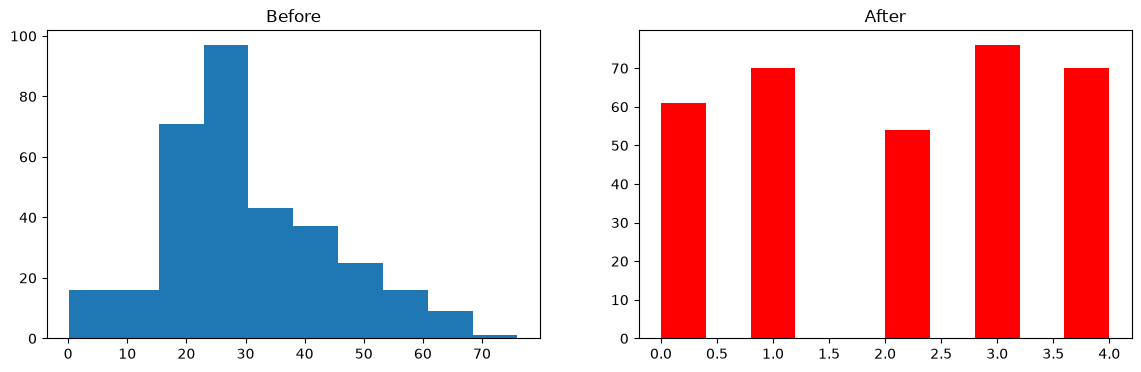

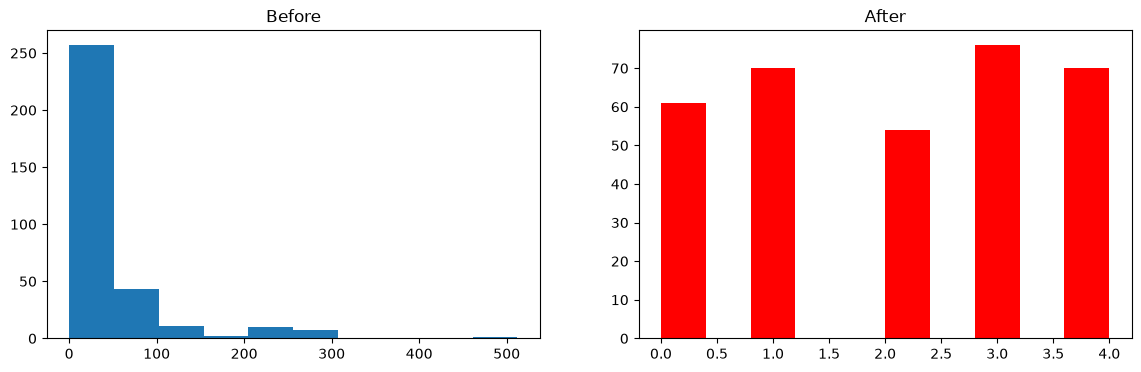

In [68]:
discretize(5,10,'quantile','kmeans')